In [1]:
import os
os.chdir(os.path.abspath(os.path.join(os.getcwd(), '..', '..')))

import torch

import json
from types import SimpleNamespace

from Model.SolarCLIP_embedfreeze import get_model_from_args
import Data.Solardataloader_subset as Solardataloader_subset

In [2]:
args_path = '/mnt/nas/home/huxing/202407/ctf/SolarCLIP_tq/configs/embed-transformer-decoder/args2.json'

with open(args_path, 'r') as f:
    args = json.load(f)
    args = SimpleNamespace(**args)

for arg in vars(args):
    print(arg, getattr(args, arg))

checkpoint_path = args.checkpoint_path
checkpoint_path +=  str(args.epochs) + '/'
checkpoint_path += args.token_type + '/'
checkpoint_path +=  str(args.inner_loss_rate) + '/'
for i in range(len(args.modal_list)):
    checkpoint_path += args.modal_list[i] + '_'
    for j in range(len(args.enhance_list[i])):
        checkpoint_path += str(args.enhance_list[i][j]) + '_'

model_checkpoint_path = checkpoint_path + '/model/'
logger_checkpoint_path = checkpoint_path + '/logger'

config_dir None
batch_size 64
learning_rate 0.1
epochs 1100
test_freq 110
save_freq 110
inner_loss_rate 1
num_workers 0
time_step 720
vision_width 768
image_resolution_mag 1024
vision_patch_size_mag 64
hidden_dropout_prob_embeddings_mag 0.1
vision_layers_mag 12
hidden_dropout_prob_transformer_mag 0.1
image_resolution_H 1024
vision_patch_size_H 64
hidden_dropout_prob_embeddings_H 0.1
vision_layers_H 12
hidden_dropout_prob_transformer_H 0.1
embed_mag_pt ./checkpoints/pretrain/log1p_magnet_cv_0094_3sgmcontinous/magnet/model/epoch_99.pt
embed_0094_pt ./checkpoints/pretrain/log1p_magnet_cv_0094_3sgmcontinous/0094/model/epoch_99.pt
token_type all embedding
modal_list ['magnet', '0094']
enhance_list [['log1p', 1], ['log1p', 1]]
image_preprocess [1024, 0.5, 90]
device cuda:2
checkpoint_path /mnt/nas/home/huxing/202407/ctf/SolarCLIP_tq/checkpoints/embedfreeze/


Text(0.5, 1.0, 'Learning Rate')

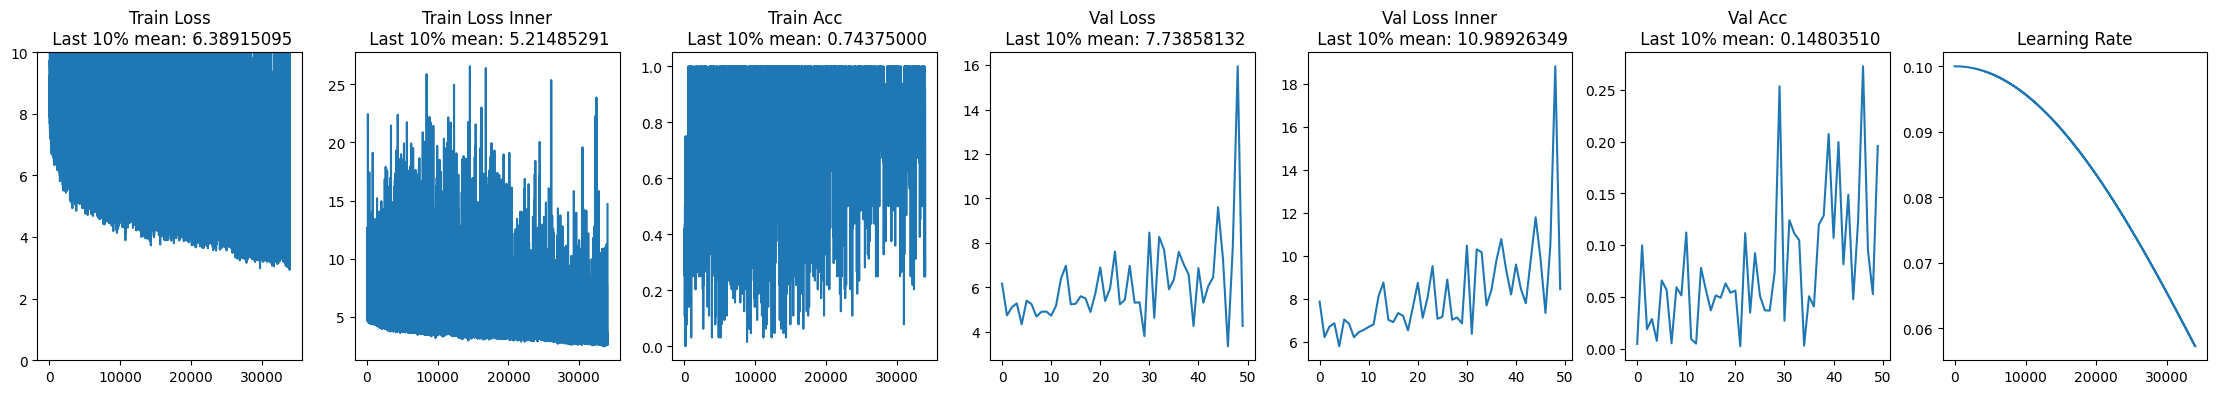

In [5]:
import matplotlib.pyplot as plt
import numpy as np
import pickle
logger_checkpoint_path = '/mnt/nas/home/huxing/202407/ctf/SolarCLIP_tq/checkpoints/embedfreeze/epochs_1100/all embedding/inner_loss_rate_1/magnet_log1p_1_0094_log1p_1_/logger'
with open(logger_checkpoint_path + '/logger_train_loss.pkl', 'rb') as f:
    logger_train_loss = pickle.load(f)
with open(logger_checkpoint_path + '/logger_train_loss_inner.pkl', 'rb') as f:
    logger_train_loss_inner = pickle.load(f)
with open(logger_checkpoint_path + '/logger_train_acc.pkl', 'rb') as f:
    logger_train_acc = pickle.load(f)
with open(logger_checkpoint_path + '/logger_val_loss.pkl', 'rb') as f:
    logger_val_loss = pickle.load(f)
with open(logger_checkpoint_path + '/logger_val_loss_inner.pkl', 'rb') as f:
    logger_val_loss_inner = pickle.load(f)
with open(logger_checkpoint_path + '/logger_val_acc.pkl', 'rb') as f:
    logger_val_acc = pickle.load(f)
with open(logger_checkpoint_path + '/logger_lr.pkl', 'rb') as f:
    logger_lr = pickle.load(f)

visualization_num = int(len(logger_val_loss)*0.1)


plt.figure(figsize=(28, 4))

plt.subplot(1,7,1)
plt.plot(logger_train_loss)
plt.ylim(0,10)
train_loss_last = np.mean(logger_train_loss[-visualization_num:])
plt.title('Train Loss\n Last 10% mean: {:.8f}'.format(train_loss_last))

plt.subplot(1,7,2)
plt.plot(logger_train_loss_inner)
train_loss_inner_last = np.mean(logger_train_loss_inner[-visualization_num:])
plt.title('Train Loss Inner\n Last 10% mean: {:.8f}'.format(train_loss_inner_last))

plt.subplot(1,7,3)
plt.plot(logger_train_acc)
train_acc_last = np.mean(logger_train_acc[-visualization_num:])
plt.title('Train Acc\n Last 10% mean: {:.8f}'.format(train_acc_last))

plt.subplot(1,7,4)
plt.plot(logger_val_loss)
val_loss_last = np.mean(logger_val_loss[-visualization_num:])
plt.title('Val Loss\n Last 10% mean: {:.8f}'.format(val_loss_last))

plt.subplot(1,7,5)
plt.plot(logger_val_loss_inner)
val_loss_inner_last = np.mean(logger_val_loss_inner[-visualization_num:])
plt.title('Val Loss Inner\n Last 10% mean: {:.8f}'.format(val_loss_inner_last))

plt.subplot(1,7,6)
plt.plot(logger_val_acc)
val_acc_last = np.mean(logger_val_acc[-visualization_num:])
plt.title('Val Acc\n Last 10% mean: {:.8f}'.format(val_acc_last))

plt.subplot(1,7,7)
plt.plot(logger_lr)
train_lr_last = np.mean(logger_lr[-visualization_num:])
plt.title('Learning Rate')



In [ ]:
from Data.utils import transfer_date_to_id
import random

def set_seed(seed):
    random.seed(seed)  # Python 内置随机数生成器
    np.random.seed(seed)  # NumPy 随机数生成器
    torch.manual_seed(seed)  # PyTorch 随机数生成器（CPU）
    torch.cuda.manual_seed(seed)  # PyTorch GPU 随机数生成器
    torch.cuda.manual_seed_all(seed)  # 所有 GPU 的随机数生成器
    torch.backends.cudnn.deterministic = True  # 确保每次结果一致
    torch.backends.cudnn.benchmark = False  # 关闭基准测试以确保一致性

set_seed(0)

device = torch.device(args.device if torch.cuda.is_available() else "cpu")
print('device:', device)

SolarModel = get_model_from_args(args).to(device)
SolarModel.load_state_dict(torch.load(model_checkpoint_path + 'epoch_250.pt')['model'])

mag_feature_list = []
h_feature_list = []
start_date = transfer_date_to_id(2020, 6, 30)
end_date = transfer_date_to_id(2024, 6, 30)
print(start_date,end_date)

random.seed(0)
val_loader = Solardataloader_subset.get_loader_by_time(load_imgs=False,time_step=12*24*60,time_interval=[start_date,end_date],modal_list = args.modal_list, enhance_list = [args.image_preprocess[0],0,0], batch_size = 30, shuffle=True, num_workers=args.num_workers)


device: cuda:2
5346720 7450560
 magnet has 72889 samples
 0094 has 120206 samples
All modal has 71 samples


In [ ]:
from Data.Solardataloader import enhance_funciton
from Solarclip_test import calculate_loss, plot_matrix_with_images
random.seed(0)

with torch.no_grad():
    SolarModel = SolarModel.eval()
    for i, data in enumerate(val_loader):
        data = data.to(device)
        modal_1 = data[:, 0, :, :, :]
        modal_2 = data[:, 1, :, :, :]
        modal_1 = enhance_funciton(modal_1, args.enhance_list[0][0], args.enhance_list[0][1])
        modal_2 = enhance_funciton(modal_2, args.enhance_list[1][0], args.enhance_list[1][1])
        data = torch.stack([modal_1, modal_2], dim=1)
        loss, loss_inner, acc, logits_per_mag, inner_cor_matrix = calculate_loss(
                SolarModel, data, args.inner_loss_rate, criterion=torch.nn.functional.cross_entropy)
        logits_per_mag = logits_per_mag/SolarModel.logit_scale.exp()
        logits_per_mag_np = logits_per_mag.cpu().numpy()

        break

print('acc:', acc)


acc: 0.5666667222976685


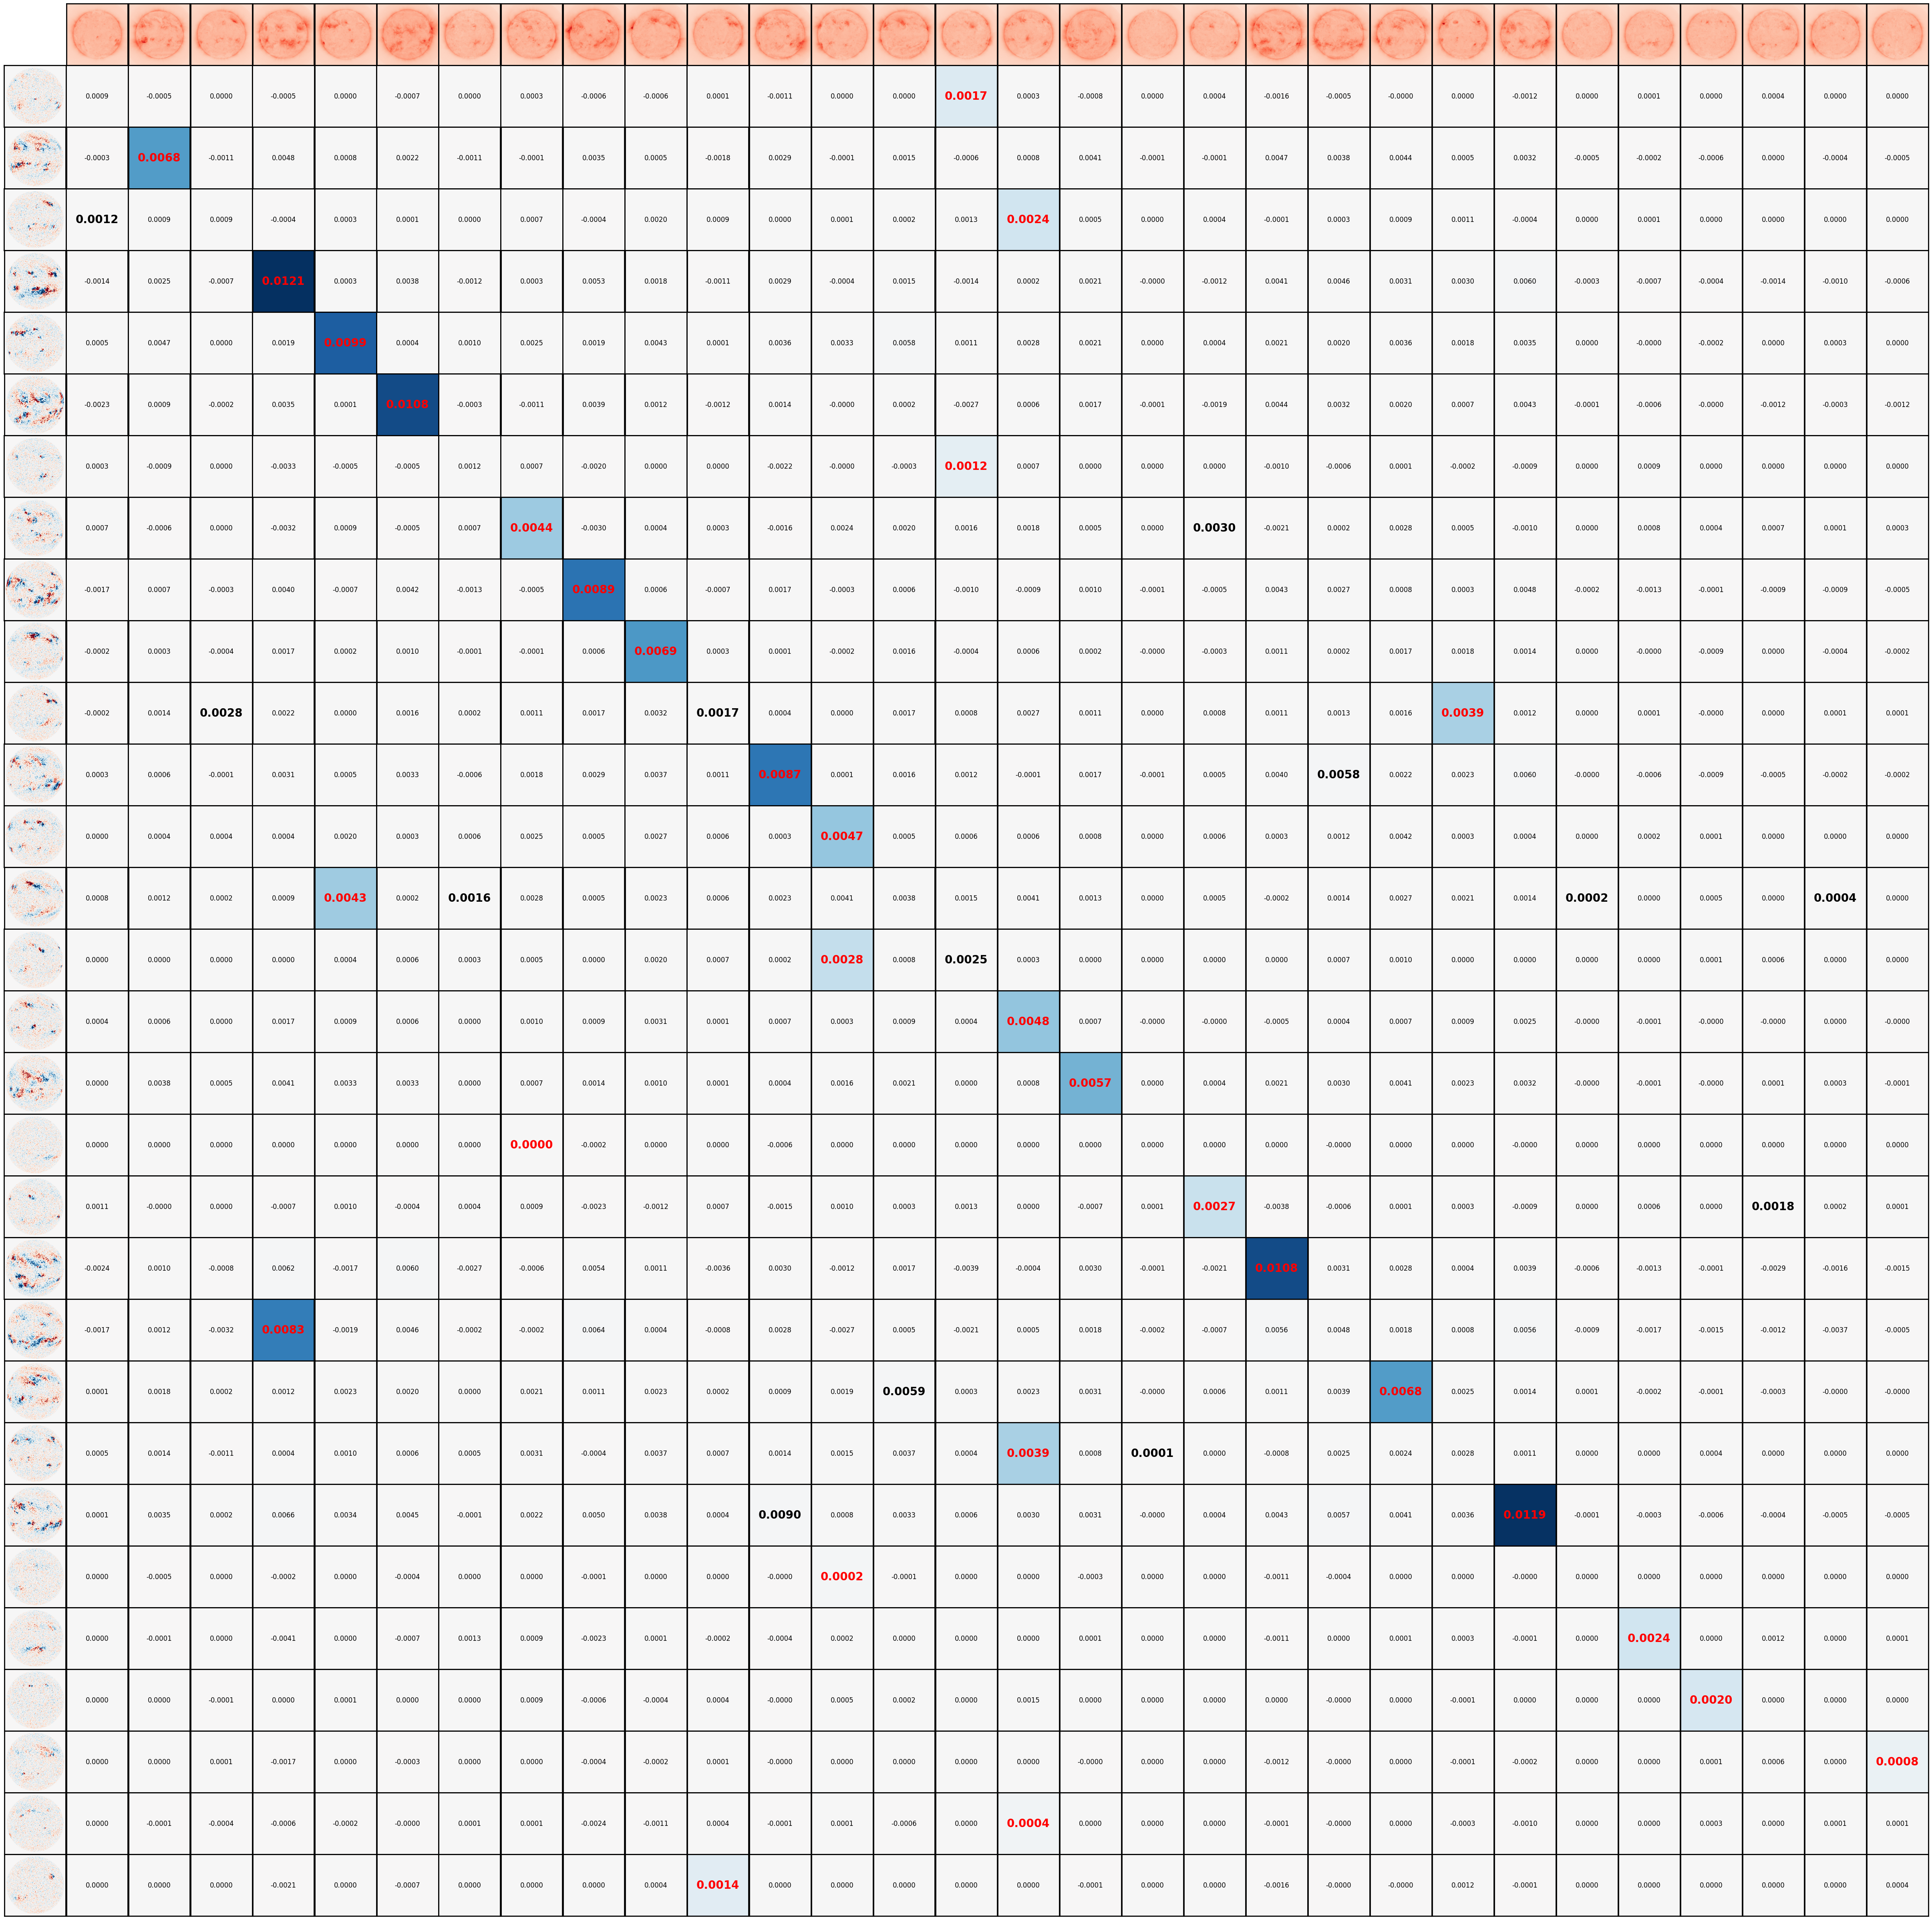

In [ ]:
vis_ids = np.arange(30)

mag_image = modal_1[vis_ids]
mag_image = mag_image.cpu().numpy()

h_image = modal_2[vis_ids]
h_image = h_image.cpu().numpy()

logits_per_mag_np = logits_per_mag_np[vis_ids,:][:,vis_ids]
plot_matrix_with_images(logits_per_mag_np,inner_cor_matrix,mag_image,h_image)